In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.table import QTable
import astropy.units as u
import cartopy.crs as ccrs
import matplotlib as mpl
from matplotlib import colors

In [2]:
# lnd_test=xr.open_dataset('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_e4_test.001/lnd/hist/b.e21.BWma1850.f19_g17.new_e4_test.001.clm2.h0.0025-03.nc')

In [3]:
# lnd_test

In [4]:
# lnd_test.TLAI[0].plot()

In [5]:
# ocn=xr.open_dataset('/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ.001/ocn/hist/b.e21.BWma1850.f19_g17.new_circ.001.pop.h.0025-09.nc')

In [6]:
# ocn

In [7]:
# lbc=xr.open_dataset('/nobackup/CESM/inputdata/atm/waccm/lb/LBC_17500116-20150116_CMIP6_0p5degLat_c180905.nc')

In [8]:
# weights=np.cos(np.deg2rad(lbc.lat))

In [9]:
# lbc.H2_LBC[-1]#.weighted(weights).mean(dim=('lat','lon'))[1200:1212].plot(label='N2O')

# minimum=np.min(lbc.N2O_LBC.weighted(weights).mean(dim=('lat','lon'))[1200:1224])
# # maximum=np.max(lbc.N2O_LBC.weighted(weights).mean(dim=('lat','lon'))[1200:1224])

# # print(minimum)
# # print(maximum)
# # print(np.mean(lbc.N2O_LBC.weighted(weights).mean(dim=('lat','lon'))[1200:1212]))

# # print(100*(maximum-np.mean(lbc.N2O_LBC.weighted(weights).mean(dim=('lat','lon'))[1200:1212]))/np.mean(lbc.N2O_LBC.weighted(weights).mean(dim=('lat','lon'))[1200:1212]))
# # print(100*(minimum-np.mean(lbc.N2O_LBC.weighted(weights).mean(dim=('lat','lon'))[1200:1212]))/np.mean(lbc.N2O_LBC.weighted(weights).mean(dim=('lat','lon'))[1200:1212]))
# # # x = abs(lbc.N2O_LBC.weighted(weights).mean(dim=('lat','lon'))[1200:1212] - lbc.N2O_LBC.weighted(weights).mean(dim=('lat','lon'))[1200:1212].mean())**2
# # # std = np.sqrt(np.mean(x)) 
# # # print(std)
# # plt.legend()

In [10]:
filepath="/nobackup/CESM/inputdata/cesm2_init/b.e21.BWma1850.f19_g17.CMIP6-piControl-WACCM-MA-2deg.001/0301-01-01/b.e21.BWma1850.f19_g17.CMIP6-piControl-WACCM-MA-2deg.001.cam.h0.0300-12.nc"

file=xr.open_dataset(filepath)


In [11]:
weights=np.cos(np.deg2rad(file.TS[0].lat))

# file.TS[0].weighted(weights).mean(dim=('lat','lon'))


In [12]:
# ctrl / to uncomment the following for animation package

from matplotlib import pyplot as plt, animation
%matplotlib inline
# This is needed to display graphics calculated outside of jupyter notebook
from IPython.display import HTML, display
# Also, in case we haven't created it yet, make sure that we have a directory for images and videos
! test -d ../images/Python_Animation && rm -rf ../images/Python_Animation/* || mkdir -p ../images/Python_Animation

In [13]:
# import CLM2 history files
File_land = "/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ_psg.001/lnd/hist/b.e21.BWma1850.f19_g17.new_circ_psg.001.clm2.h0.0014-04.nc" #file name
DataSet_land = xr.open_dataset(File_land) #open the file
File_CAM = "/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ.001/atm/hist/b.e21.BWma1850.f19_g17.new_circ.001.cam.h0.0002-03.nc" #file name
DataSet_CAM = xr.open_dataset(File_CAM) #open the file

# creating land/ocean mask
# we can only assign a new coord to the data set (main), but not the data array(variables)
# we should truncate the very large orginal .nc file into smaller .nc file with requried variables
# to save the Jupyter notebook memory and allow it to run (hint: ncrcat)
DataSet_CAM = xr.open_dataset(File_CAM) #open the file
DataSet_CAM.coords['mask'] = (('lat', 'lon'), DataSet_land.landmask)

In [14]:
# Auto file input
var_flux    =["SOLIN","FLNT","FSNT","FSUTOA"]       #  +["FSNS","FLNS","FLDS","FLUT"]
var_clearsky=[]#["FLNTC","FSNTC"]    #  +["FSNSC","FLUTC"]
var_state   =["T","TS","ICEFRAC","H2O","PS"]     +["ASDIF"]
var_cloud   =[]#["CLDTOT","CLDLOW","CLDMED","CLDHGH","CLOUD","CLDICE","SWCF","LWCF","TGCLDLWP"]
var_precip  =["Q"]#["PRECC","PRECL","TMQ","LHFLX","RELHUM"]
var_dynamic =["VT","VQ","U","V"]

output_var=var_flux+var_clearsky+var_state+var_cloud+var_precip+var_dynamic

data_directory = ['/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ.001/atm/hist/',
                '/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_e4_test.001/atm/hist/']

filepath=[[],[]]

e_range=["_circ","_e4"]


for i in range(len(data_directory)):  
    if i==0:  
        for j in range(len(output_var)):
            filepath[i].append(data_directory[i]+output_var[j]+ e_range[i] +'_obl0.nc') 
            ds_circ=xr.merge([xr.open_mfdataset(filepath[i])])
    if i==1:
        for j in range(len(output_var)):
            filepath[i].append(data_directory[i]+output_var[j] +'_merge.nc')
            ds_e4=xr.merge([xr.open_mfdataset(filepath[i])])

In [15]:
# Auto file input

var_state   =["SNOW_DEPTH","TLAI"]     

output_var=var_state

data_directory = ['/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_circ.001/lnd/hist/',
                '/nobackup/pybl/cesm_sims/archive/b.e21.BWma1850.f19_g17.new_e4_test.001/lnd/hist/']

filepath=[[],[]]

e_range=["_circ","_e4"]

for i in range(len(data_directory)):  
    if i==0:  
        for j in range(len(output_var)):
            filepath[i].append(data_directory[i]+output_var[j]+ e_range[i] +'_obl0.nc') 
            ds_circ_lnd=xr.merge([xr.open_mfdataset(filepath[i])])
    if i==1:
        for j in range(len(output_var)):
            filepath[i].append(data_directory[i]+output_var[j] +'_merge.nc')
            ds_e4_lnd=xr.merge([xr.open_mfdataset(filepath[i])])

In [16]:
# A=ds_e4_lnd.SNOW_DEPTH.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))
# B=ds_circ_lnd.SNOW_DEPTH.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))


# plt.figure(figsize=(10,8))

# A.plot(label='e=0.4',color='red')
# A['var'] = (['month'], A.values)
# plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, mean')
# B['var'] = (['month'], B.values)
# plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, mean')
# B.plot(label='e=0',color='blue')
# plt.legend(fontsize=20)
# plt.ylabel("SNOW_DEPTH",fontsize=20)
# plt.xlabel("Month",fontsize=20)
# plt.tick_params(labelsize=20)
# plt.minorticks_on()


In [17]:
def weighted_temporal_mean(ds, var):
    """
    weight by days in each month
    """
    # Determine the month length
    month_length = ds.time.dt.days_in_month
    # Calculate the weights
    wgts = month_length.groupby("time.year") / month_length.groupby("time.year").sum()
    # Make sure the weights in each year add up to 1
    np.testing.assert_allclose(wgts.groupby("time.year").sum(xr.ALL_DIMS), 1.0)
    # Subset our dataset for our variable
    obs = ds[var]
    # Setup our masking for nan values
    cond = obs.isnull()
    ones = xr.where(cond, 0.0, 1.0)
    # Calculate the numerator
    obs_sum = (obs * wgts).resample(time="AS").sum(dim="time")
    # Calculate the denominator
    ones_out = (ones * wgts).resample(time="AS").sum(dim="time")
    # Return the weighted average
    return obs_sum / ones_out


def weighted_annual_mean(ds):
    month_length=ds_circ.T.sel(time=slice('0012-01', '0012-12')).time.dt.days_in_month
    month_length=month_length.groupby("time.month").sum()
    weights_month = month_length/365
    np.testing.assert_allclose(weights_month.sum().values, np.ones(1))
    ds_weighted = (ds["var"]*weights_month).sum()
    return ds_weighted

# note for weighted_annual_mean(ds):
# This function may be used when there is variable to call in the data array
# But you need to do something like the following:
# F=B+D
# F['var'] = (['month'], F.values)

In [18]:
# xarray functions

# annual mean2D lat&lon 
def latlon2D(ds,var_name,timeslice):
    output=weighted_temporal_mean(ds.sel(time=timeslice),var_name).mean(dim='time')
    return output
# annual mean2D lat&lon, monthly mean function
def latlon2D_month(dsvar,timeslice,month):
    output=dsvar.sel(time=timeslice).groupby('time.month').mean(dim='time').sel(month=month)
    return output

# line plot, interannual trend of global mean (IAT_GM)
def IAT_GM(ds,var_name,timeslice):
    output=weighted_temporal_mean(ds.sel(time=timeslice),var_name).weighted(weights).mean(dim=('lat','lon'))
    return output

# line plot, interseasonal trend of global mean (IAT_GM)
def IST_GM(ds_var,timeslice):
    output=ds_var.sel(time=timeslice).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))
    return output


# zonal mean 2D time x-axis

# global mean vertical 2D time x-axis


In [97]:
# plotting functions

def plot_latlon2D(x,title,colorbar_label,**kwargs):

    vmin = kwargs.get('vmin', None)
    vmax = kwargs.get('vmax', None)
    unit_converter = kwargs.get('unit_converter', None)
    colormap = kwargs.get('colormap', None)
    discrete_num=kwargs.get('discrete_num', None)    
    
    gs = gridspec.GridSpec(2, 1)
    plt.figure(figsize=(11,15))
    plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

    ax = plt.subplot(gs[0, 0],projection=ccrs.Robinson()) # row 0, col 0
    ax.set_global() 
    ax.coastlines()
    fg=(x*unit_converter).plot(cmap=colormap,transform=ccrs.PlateCarree(),vmin=vmin,vmax=vmax,levels=discrete_num)
    plt.tick_params(labelsize=20)
    plt.minorticks_on()
    fg.colorbar.ax.tick_params(labelsize=15)
    fg.colorbar.set_label(label=colorbar_label, size=15)
    if discrete_num==3:
        fg.colorbar.set_ticklabels(["<30 cm/yr",">30 cm/yr"])
        fg.colorbar.set_ticks([0, 1])
    if discrete_num==13:
        fg.colorbar.set_ticks(list(range(0,13,1)))

    plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)
    plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)
    
    plt.title(title,fontsize=15)



    return(fg)

In [ ]:
# plotting functions

def plot_latlon2D(x,title,colorbar_label,**kwargs):

    vmin = kwargs.get('vmin', None)
    vmax = kwargs.get('vmax', None)
    unit_converter = kwargs.get('unit_converter', None)
    colormap = kwargs.get('colormap', None)
    discrete_num=kwargs.get('discrete_num', None)    
    
    gs = gridspec.GridSpec(2, 1)
    plt.figure(figsize=(11,15))
    plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

    ax = plt.subplot(gs[0, 0],projection=ccrs.Robinson()) # row 0, col 0
    ax.set_global() 
    ax.coastlines()
    fg=(x*unit_converter).plot(cmap=colormap,transform=ccrs.PlateCarree(),vmin=vmin,vmax=vmax,levels=discrete_num)
    plt.tick_params(labelsize=20)
    plt.minorticks_on()
    fg.colorbar.ax.tick_params(labelsize=15)
    fg.colorbar.set_label(label=colorbar_label, size=15)
    if discrete_num==3:
        fg.colorbar.set_ticklabels(["<30 cm/yr",">30 cm/yr"])
        fg.colorbar.set_ticks([0, 1])
    if discrete_num==13:
        fg.colorbar.set_ticks(list(range(0,13,1)))

    plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)
    plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)
    
    plt.title(title,fontsize=15)



    return(fg)

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


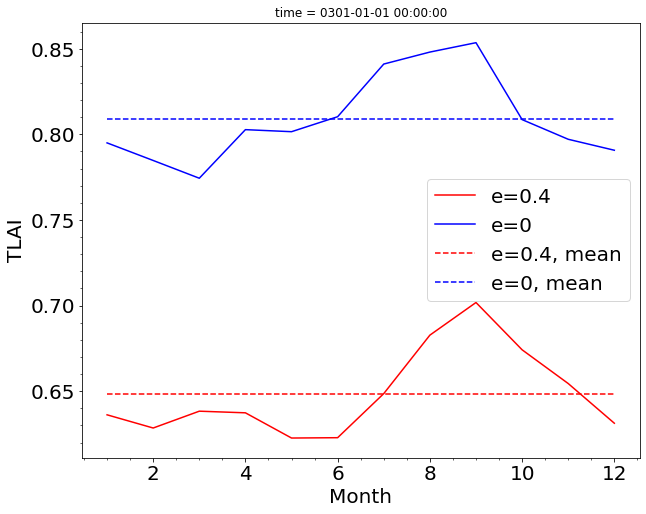

In [20]:
A=ds_e4_lnd.TLAI.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))
B=ds_circ_lnd.TLAI.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))


plt.figure(figsize=(10,8))

A.plot(label='e=0.4',color='red')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, mean')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, mean')
B.plot(label='e=0',color='blue')
plt.legend(fontsize=20)
plt.ylabel("TLAI",fontsize=20)
plt.xlabel("Month",fontsize=20)
plt.tick_params(labelsize=20)
plt.minorticks_on()


In [21]:
# weights=np.cos(np.deg2rad(DataSet_CAM.TS.lat))

In [22]:
# DataSet_CAM.AEROD_v[0]#.weighted(weights).mean(dim=('lat','lon'))

In [23]:
# DataSet_CAM

In [24]:
DataSet_CAM.FSDS[0].weighted(weights).mean(dim=('lat','lon'))-DataSet_CAM.FSNS[0].weighted(weights).mean(dim=('lat','lon'))#+DataSet_CAM.FSUTOA[0].weighted(weights).mean(dim=('lat','lon'))

<xarray.DataArray ()>
array(23.27460724)

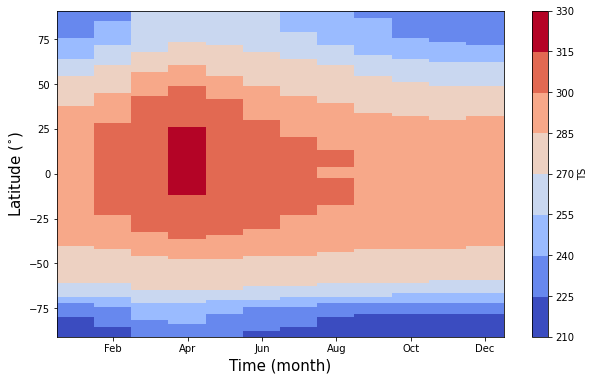

In [90]:
plt.figure(figsize=(10,6))
ds_e4.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').mean(dim='lon').plot(x='month',cmap="coolwarm",levels =11)

plt.xlabel("Time (month)", fontsize=15)
plt.ylabel("Latitude ($^{\circ}$)",fontsize=15)

Numbers   = np.array([2,4,6,8,10,12]) # First day of each month
my_xticks = ['Feb','Apr','Jun','Aug','Oct','Dec']
plt.xticks(Numbers, my_xticks)

plt.savefig("TS_trend.png",dpi=200,bbox_inches="tight")

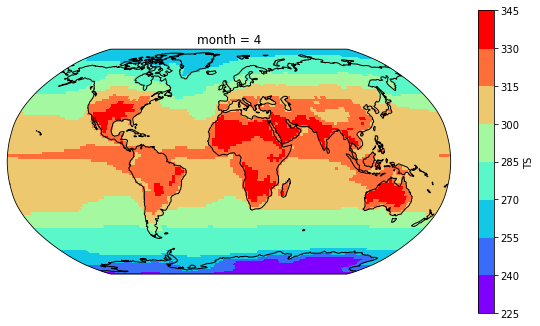

In [26]:
gs = gridspec.GridSpec(2, 1)
plt.figure(figsize=(11,15))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

ax = plt.subplot(gs[0, 0],projection=ccrs.Robinson()) # row 0, col 0
ax.set_global() 
ax.coastlines()

ds_e4.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').sel(month=4).plot(cmap="rainbow",levels =11,transform=ccrs.PlateCarree())

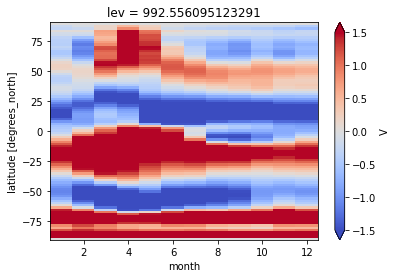

In [27]:
ds_e4.V.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').mean(dim='lon').isel(lev=-1).plot(x="month",vmin=-1.5,vmax=1.5,cmap='coolwarm')

#.plot(x='month',cmap="coolwarm")

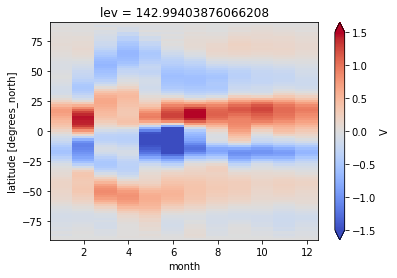

In [28]:
ds_e4.V.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').mean(dim='lon').isel(lev=-20).plot(x="month",vmin=-1.5,vmax=1.5,cmap='coolwarm')

In [29]:
ds_circ['EEI'] = (ds_circ.FSNT-ds_circ.FLNT)

ds_circ['EEI'].attrs["long_name"]="Top of Model Energy Imbalance"
ds_circ['EEI'].attrs["units"]="w/m2"
ds_circ['EEI'].attrs["cell_methods"]="time:mean"

ds_e4['EEI'] = (ds_e4.FSNT-ds_e4.FLNT)

ds_e4['EEI'].attrs["long_name"]="Top of Model Energy Imbalance"
ds_e4['EEI'].attrs["units"]="w/m2"
ds_e4['EEI'].attrs["cell_methods"]="time:mean"

In [30]:
ds_circ['ALBEDO'] = (ds_circ.FSUTOA/(ds_circ.FSUTOA+ds_circ.FSNT))

ds_circ['ALBEDO'].attrs["long_name"]="Planetary Albedo"
ds_circ['ALBEDO'].attrs["units"]="fraction"
ds_circ['ALBEDO'].attrs["cell_methods"]="time:mean"

ds_e4['ALBEDO'] = (ds_e4.FSUTOA/(ds_e4.FSUTOA+ds_e4.FSNT))

ds_e4['ALBEDO'].attrs["long_name"]="Planetary Albedo"
ds_e4['ALBEDO'].attrs["units"]="fraction"
ds_e4['ALBEDO'].attrs["cell_methods"]="time:mean"

FSNT,e=0.4 243.476
FSNT,e=0 237.155
FLNT,e=0.4 244.428
FLNT,e=0 239.686
EEI,e=0.4 -0.952
EEI,e=0 -2.531
FSUTOA,e=0.4 97.559
FSUTOA,e=0 103.023
ALBEDO,e=0.4 33.55
ALBEDO,e=0 34.118
TS,e=0.4 289.571
TS,e=0 287.711


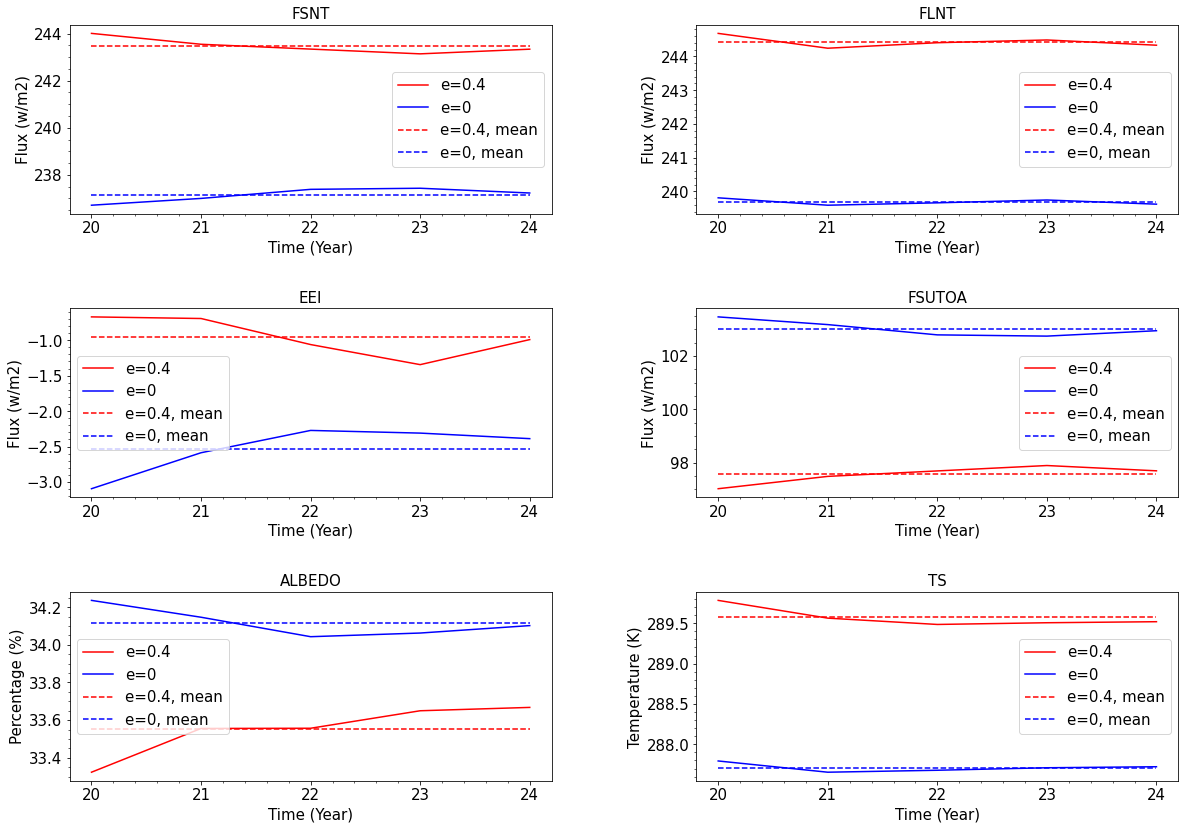

In [31]:
gs = gridspec.GridSpec(3, 2)
plt.figure(figsize=(22,15))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.3, 
                    hspace=0.5)
##########################################################################################
plt.subplot(gs[0, 0]) # row 0, col 0

A=(IAT_GM(ds_e4,"FSNT",timeslice=slice('0020-01', '0024-12')))
time=A.time.dt.year
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=(IAT_GM(ds_circ,"FSNT",timeslice=slice('0020-01', '0024-12')))
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")

plt.title("FSNT",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Flux (w/m2)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()


print("FSNT,e=0.4",round(np.mean(A).values.tolist(),3))
print("FSNT,e=0",round(np.mean(B).values.tolist(),3))
##########################################################################################
plt.subplot(gs[0, 1]) # row 0, col 0

A=(IAT_GM(ds_e4,"FLNT",timeslice=slice('0020-01', '0024-12')))
time=A.time.dt.year
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=(IAT_GM(ds_circ,"FLNT",timeslice=slice('0020-01', '0024-12')))
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")


plt.title("FLNT",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Flux (w/m2)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()

print("FLNT,e=0.4",round(np.mean(A).values.tolist(),3))
print("FLNT,e=0",round(np.mean(B).values.tolist(),3))
##########################################################################################
plt.subplot(gs[1, 0]) # row 1, col 0

A=(IAT_GM(ds_e4,"EEI",timeslice=slice('0020-01', '0024-12')))
time=A.time.dt.year
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=(IAT_GM(ds_circ,"EEI",timeslice=slice('0020-01', '0024-12')))
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")


plt.title("EEI",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Flux (w/m2)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()

print("EEI,e=0.4",round(np.mean(A).values.tolist(),3))
print("EEI,e=0",round(np.mean(B).values.tolist(),3))

##########################################################################################
plt.subplot(gs[1, 1]) # row 1, col 0

A=(IAT_GM(ds_e4,"FSUTOA",timeslice=slice('0020-01', '0024-12')))
time=A.time.dt.year
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=(IAT_GM(ds_circ,"FSUTOA",timeslice=slice('0020-01', '0024-12')))
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")

plt.title("FSUTOA",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Flux (w/m2)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()

print("FSUTOA,e=0.4",round(np.mean(A).values.tolist(),3))
print("FSUTOA,e=0",round(np.mean(B).values.tolist(),3))

##########################################################################################
plt.subplot(gs[2, 0]) # row 1, col 0
A=100*(IAT_GM(ds_e4,"ALBEDO",timeslice=slice('0020-01', '0024-12')))
time=A.time.dt.year
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=100*(IAT_GM(ds_circ,"ALBEDO",timeslice=slice('0020-01', '0024-12')))
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")

plt.title("ALBEDO",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Percentage (%)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()

print("ALBEDO,e=0.4",round(np.mean(A).values.tolist(),3))
print("ALBEDO,e=0",round(np.mean(B).values.tolist(),3))


##########################################################################################

plt.subplot(gs[2, 1]) # row 1, col 0
A=(IAT_GM(ds_e4,"TS",timeslice=slice('0020-01', '0024-12')))
time=A.time.dt.year
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=(IAT_GM(ds_circ,"TS",timeslice=slice('0020-01', '0024-12')))
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")

plt.title("TS",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Temperature (K)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()

print("TS,e=0.4",round(np.mean(A).values.tolist(),3))
print("TS,e=0",round(np.mean(B).values.tolist(),3))

plt.savefig("EnergyBalance.png",dpi=200,bbox_inches="tight")

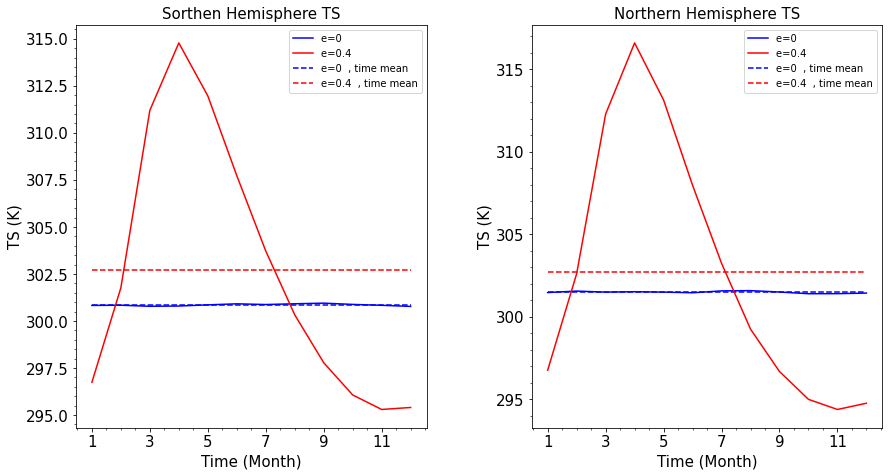

In [73]:
gs = gridspec.GridSpec(1, 2)
plt.figure(figsize=(16,8))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.3, 
                    hspace=0.5)
##########################################################################################

plt.subplot(gs[0, 0]) # row 0, col 0

A=ds_circ.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

# tropical: A=A.where(A.lat<0).where(A.lat>-25)

# mid-lat:  A=A.where(A.lat<-25).where(A.lat>-50)

# high-lat: A=A.where(A.lat<-50)

A=A.where(A.lat<0).where(A.lat>-25)

A=A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0  ')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0  , time mean')

B=ds_e4.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')
B=B.where(B.lat<0).where(B.lat>-25)
B=B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4  ')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4  , time mean')

plt.title("Sorthen Hemisphere TS",fontsize=15)
plt.xlabel("Time (Month)", fontsize=15)
plt.ylabel("TS (K)",fontsize=15)
plt.legend(fontsize=10)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(1, 13, 2.0))
plt.minorticks_on()

##########################################################################################

plt.subplot(gs[0, 1]) # row 0, col 0

A=ds_circ.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

A=A.where(A.lat>0).where(A.lat<25)
A=A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0  ')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0  , time mean')

B=ds_e4.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

B=B.where(B.lat>0).where(B.lat<25)
B=B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4  ')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4  , time mean')

plt.title("Northern Hemisphere TS",fontsize=15)
plt.xlabel("Time (Month)", fontsize=15)
plt.ylabel("TS (K)",fontsize=15)
plt.legend(fontsize=10)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(1, 13, 2.0))
plt.minorticks_on()

ASDIF,e=0.4 58.784
ASDIF,e=0 59.312
Sea-ice Fraction, e=0.4 5.479
Sea-ice Fraction, e=0 5.608


/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.p

SNOW DEPTH,e=0.4 0.052
SNOW DEPTH,e=0 1.374


/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: inval

Snow Coverage, e=0.4 19.257
Snow Coverage, e=0 24.138


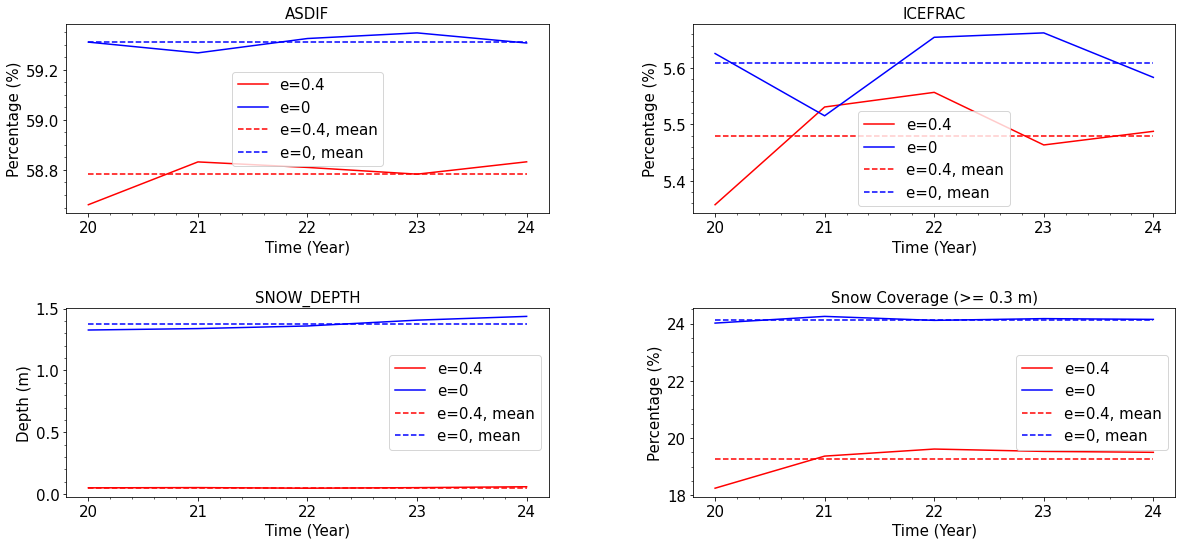

In [33]:
gs = gridspec.GridSpec(3, 2)
plt.figure(figsize=(22,15))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.3, 
                    hspace=0.5)
##########################################################################################
plt.subplot(gs[0, 0]) # row 0, col 0

A=100*(IAT_GM(ds_e4,"ASDIF",timeslice=slice('0020-01', '0024-12')))
time=A.time.dt.year
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=100*(IAT_GM(ds_circ,"ASDIF",timeslice=slice('0020-01', '0024-12')))
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")


plt.title("ASDIF",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Percentage (%)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()

print("ASDIF,e=0.4",round(np.mean(A).values.tolist(),3))
print("ASDIF,e=0",round(np.mean(B).values.tolist(),3))
##########################################################################################
plt.subplot(gs[0, 1]) # row 0, col 0

A=100*(IAT_GM(ds_e4,"ICEFRAC",timeslice=slice('0020-01', '0024-12')))
time=A.time.dt.year
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=100*(IAT_GM(ds_circ,"ICEFRAC",timeslice=slice('0020-01', '0024-12')))
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")

plt.title("ICEFRAC",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Percentage (%)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()

print("Sea-ice Fraction, e=0.4",round(np.mean(A).values.tolist(),3))
print("Sea-ice Fraction, e=0",round(np.mean(B).values.tolist(),3))
# ##########################################################################################
plt.subplot(gs[1, 0]) # row 1, col 0

A=(IAT_GM(ds_e4_lnd,"SNOW_DEPTH",timeslice=slice('0020-01', '0024-12')))
time=A.time.dt.year
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=(IAT_GM(ds_circ_lnd,"SNOW_DEPTH",timeslice=slice('0020-01', '0024-12')))
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")


plt.title("SNOW_DEPTH",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Depth (m)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()

print("SNOW DEPTH,e=0.4",round(np.mean(A).values.tolist(),3))
print("SNOW DEPTH,e=0",round(np.mean(B).values.tolist(),3))

# ##########################################################################################
plt.subplot(gs[1, 1]) # row 1, col 0
##################################################
ts1=slice('0020-01', '0020-12')
ts2=slice('0021-01', '0021-12')
ts3=slice('0022-01', '0022-12')
ts4=slice('0023-01', '0023-12')
ts5=slice('0024-01', '0024-12')
ts=[ts1,ts2,ts3,ts4,ts5]
x_snow_e4=[]
x_snow_e0=[]
AREA_tot      = DataSet_CAM.AREA[0,:,:].where(DataSet_CAM.mask == 1).sum()
for i in range(len(ts)):
    AM_SNOWDEPTH_e4   = weighted_temporal_mean(ds_e4_lnd.sel(time=ts[i]),"SNOW_DEPTH").mean(dim='time')
    AM_SNOWDEPTH_circ = weighted_temporal_mean(ds_circ_lnd.sel(time=ts[i]),"SNOW_DEPTH").mean(dim='time')
    ds_circ.coords['mask_snow'] = (('lat', 'lon'), AM_SNOWDEPTH_circ)
    ds_e4.coords['mask_snow'] = (('lat', 'lon'), AM_SNOWDEPTH_e4)
    x_snow_e4.append(DataSet_CAM.AREA[0,:,:].where(ds_e4.mask_snow >=0.3).sum().values/AREA_tot)
    x_snow_e0.append(DataSet_CAM.AREA[0,:,:].where(ds_circ.mask_snow >=0.3).sum().values/AREA_tot)
##################################################
                                   
A=[i*100 for i in x_snow_e4]
time=[20,21,22,23,24]
plt.plot(time, A,label='e=0.4',color='red')
plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

B=[i*100 for i in x_snow_e0]
plt.plot(time, B,label='e=0',color='blue')
plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")

plt.title("Snow Coverage (>= 0.3 m)",fontsize=15)
plt.xlabel("Time (Year)", fontsize=15)
plt.ylabel("Percentage (%)",fontsize=15)
plt.legend(fontsize=15)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
plt.minorticks_on()

print("Snow Coverage, e=0.4",round(np.mean(A),3))
print("Snow Coverage, e=0",round(np.mean(B),3))

# ##########################################################################################
# plt.subplot(gs[2, 0]) # row 1, col 0
# A=(IAT_GM(ds_e4,"ALBEDO",timeslice=slice('0020-01', '0024-12')))
# time=A.time.dt.year
# plt.plot(time, A,label='e=0.4',color='red')
# plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

# B=(IAT_GM(ds_circ,"ALBEDO",timeslice=slice('0020-01', '0024-12')))
# plt.plot(time, B,label='e=0',color='blue')
# plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")

# plt.title("ALBEDO",fontsize=15)
# plt.xlabel("Time (Year)", fontsize=15)
# plt.ylabel("Fraction",fontsize=15)
# plt.legend(fontsize=15)
# plt.tick_params(labelsize=15)
# plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
# plt.minorticks_on()

# print("ALBEDO,e=0.4",round(np.mean(A).values.tolist(),3))
# print("ALBEDO,e=0",round(np.mean(B).values.tolist(),3))


# ##########################################################################################

# plt.subplot(gs[2, 1]) # row 1, col 0
# A=(IAT_GM(ds_e4,"TS",timeslice=slice('0020-01', '0024-12')))
# time=A.time.dt.year
# plt.plot(time, A,label='e=0.4',color='red')
# plt.hlines(np.mean(A),xmin=time[0],xmax=time[-1],color='red',linestyle='--',label="e=0.4, mean")

# B=(IAT_GM(ds_circ,"TS",timeslice=slice('0020-01', '0024-12')))
# plt.plot(time, B,label='e=0',color='blue')
# plt.hlines(np.mean(B),xmin=time[0],xmax=time[-1],color='blue',linestyle='--',label="e=0, mean")

# plt.title("TS",fontsize=15)
# plt.xlabel("Time (Year)", fontsize=15)
# plt.ylabel("Temperature (K)",fontsize=15)
# plt.legend(fontsize=15)
# plt.tick_params(labelsize=15)
# plt.xticks(np.arange(time[0], time[-1]+1, 1.0))
# plt.minorticks_on()

# print("TS,e=0.4",round(np.mean(A).values.tolist(),3))
# print("TS,e=0",round(np.mean(B).values.tolist(),3))

plt.savefig("Albedo_AM.png",dpi=400,bbox_inches="tight")

In [34]:
A=(IAT_GM(ds_e4,"EEI",timeslice=slice('0020-01', '0020-12'))).values.tolist()[0]
B=(IAT_GM(ds_e4,"EEI",timeslice=slice('0021-01', '0021-12'))).values.tolist()[0]
C=(IAT_GM(ds_e4,"EEI",timeslice=slice('0022-01', '0022-12'))).values.tolist()[0]
D=(IAT_GM(ds_e4,"EEI",timeslice=slice('0023-01', '0023-12'))).values.tolist()[0]
E=(IAT_GM(ds_e4,"EEI",timeslice=slice('0024-01', '0024-12'))).values.tolist()[0]
M=(IAT_GM(ds_e4,"EEI",timeslice=slice('0020-01', '0024-12'))).mean(dim='time').values.tolist()

x_i=[A,B,C,D,E]
SUMM=0
for i in range(len(x_i)):
    
    SUMM += ((x_i[i]-M)**2)

Var_EEI=np.sqrt(SUMM/5)

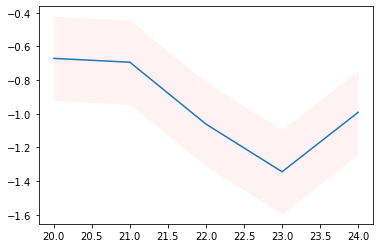

In [35]:
# plt.errorbar([1,2,3,4,5], (IAT_GM(ds_e4,"EEI",timeslice=slice('0020-01', '0024-12'))), Var_EEI)

y=IAT_GM(ds_e4,"EEI",timeslice=slice('0020-01', '0024-12'))
x=IAT_GM(ds_e4,"EEI",timeslice=slice('0020-01', '0024-12')).time.dt.year
plt.plot(x,y)
error=Var_EEI
plt.fill_between(x, y-error, y+error,color='pink',alpha=.2, linewidth=0)

In [36]:
IAT_GM(ds_e4,"EEI",timeslice=slice('0020-01', '0024-12')).time.dt.year[0]

<xarray.DataArray 'year' ()>
array(20)
Coordinates:
    time     object 0020-01-01 00:00:00

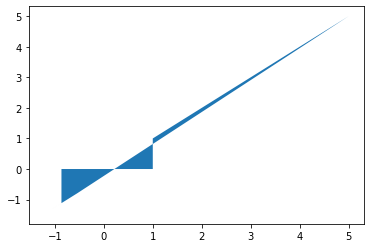

In [37]:
A=((IAT_GM(ds_e4,"EEI",timeslice=slice('0020-01', '0024-12')))+Var_EEI/2)#.plot()

B=((IAT_GM(ds_e4,"EEI",timeslice=slice('0020-01', '0024-12')))-Var_EEI/2)#.plot()

plt.fill_between(np.append([1,2,3,4,5],A),
                 np.append([1,2,3,4,5],B))

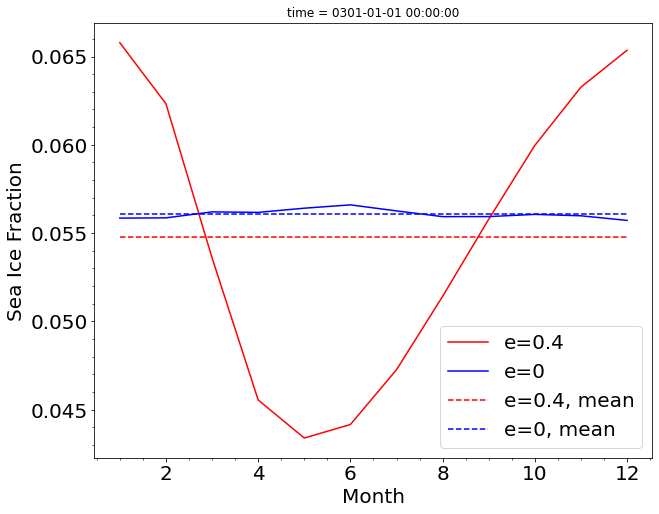

In [38]:
A=ds_e4.ICEFRAC.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))
B=ds_circ.ICEFRAC.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))


plt.figure(figsize=(10,8))

A.plot(label='e=0.4',color='red')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, mean')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, mean')
B.plot(label='e=0',color='blue')
plt.legend(fontsize=20)
plt.ylabel("Sea Ice Fraction",fontsize=20)
plt.xlabel("Month",fontsize=20)
plt.tick_params(labelsize=20)
plt.minorticks_on()


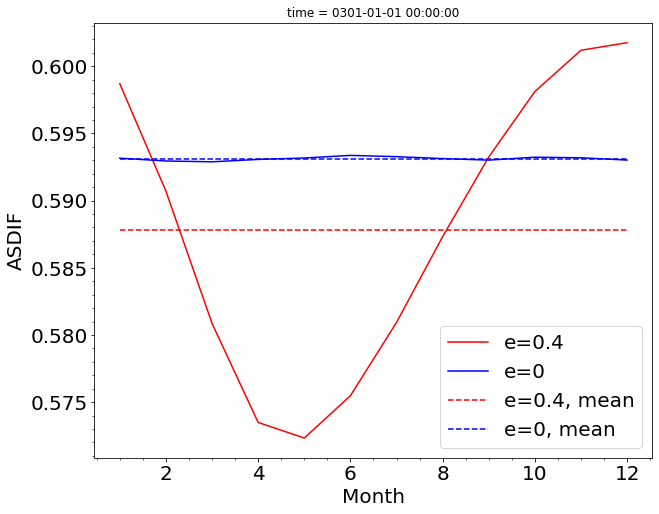

In [39]:
A=ds_e4.ASDIF.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))
B=ds_circ.ASDIF.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))


plt.figure(figsize=(10,8))

A.plot(label='e=0.4',color='red')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, mean')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, mean')
B.plot(label='e=0',color='blue')
plt.legend(fontsize=20)
plt.ylabel("ASDIF",fontsize=20)
plt.xlabel("Month",fontsize=20)
plt.tick_params(labelsize=20)
plt.minorticks_on()


/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


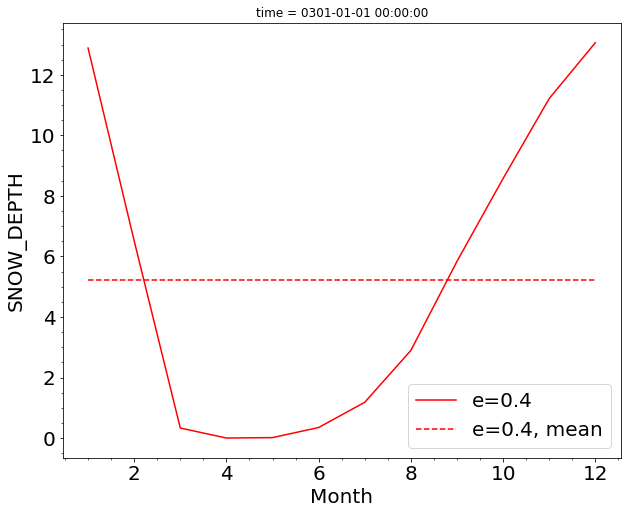

In [40]:
A=ds_e4_lnd.SNOW_DEPTH.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))
B=ds_circ_lnd.SNOW_DEPTH.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))


plt.figure(figsize=(10,8))

(100*A).plot(label='e=0.4',color='red')
A['var'] = (['month'], A.values)
plt.hlines(100*weighted_annual_mean(A),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, mean')
# B['var'] = (['month'], B.values)
# plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, mean')
# B.plot(label='e=0',color='blue')
plt.legend(fontsize=20)
plt.ylabel("SNOW_DEPTH",fontsize=20)
plt.xlabel("Month",fontsize=20)
plt.tick_params(labelsize=20)
plt.minorticks_on()


In [41]:
days_c,eccf_c,declin_c,zeros_c = np.loadtxt('output_circular_zero_obl.txt',unpack=True)
dist_c=np.sqrt(1/eccf_c)

days_circ_e04,eccf_circ_e04 = np.loadtxt('calday_circ_eccf_e04_12.txt',unpack=True)
dist_circ_e04=np.sqrt(1/(eccf_circ_e04*0.9175670673778245))


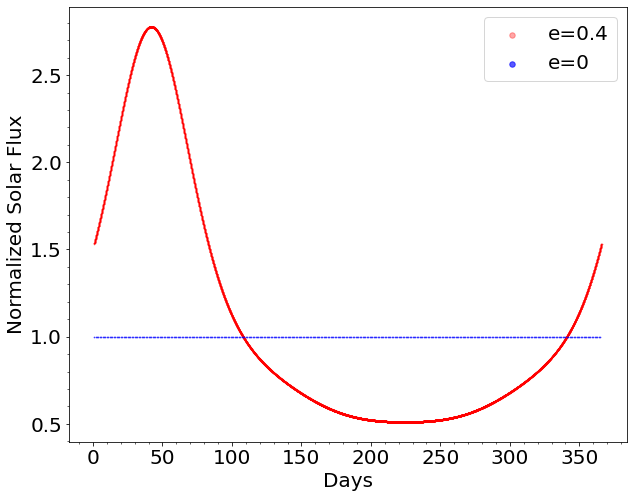

In [42]:
plt.figure(figsize=(10,8))

A=days_circ_e04

B=eccf_circ_e04

plt.scatter(A,B,s=0.35,label='e=0.4',alpha=0.35,color='red',marker='o')
plt.scatter(days_c,eccf_c,s=0.6,label='e=0',alpha=0.65,color='blue',marker='o')

lgnd = plt.legend(loc="upper right", scatterpoints=1, fontsize=20)
lgnd.legendHandles[0]._sizes = [30]
lgnd.legendHandles[1]._sizes = [30]

plt.ylabel("Normalized Solar Flux",fontsize=20)
plt.xlabel("Days",fontsize=20)
plt.tick_params(labelsize=20)
plt.minorticks_on()

# plt.savefig("SOLAR_FLUX.png",dpi=400,bbox_inches="tight")

364.0


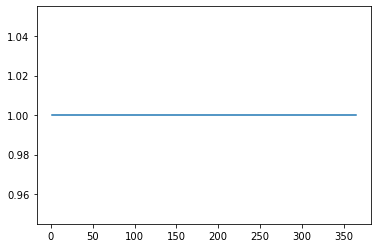

In [43]:
import numpy as np
# x = A
# y = B
x=days_c
y=eccf_c
plt.plot(x,y)

def integrate(x, y):
    area = np.trapz(y=y, x=x)
    return area
print(integrate(x, y))

In [44]:
x

array([  1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,  66.,
        67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,  77.,
        78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,  88.,
        89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,  99.,
       100., 101., 102., 103., 104., 105., 106., 107., 108., 109., 110.,
       111., 112., 113., 114., 115., 116., 117., 118., 119., 120., 121.,
       122., 123., 124., 125., 126., 127., 128., 129., 130., 131., 132.,
       133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
       144., 145., 146., 147., 148., 149., 150., 15

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


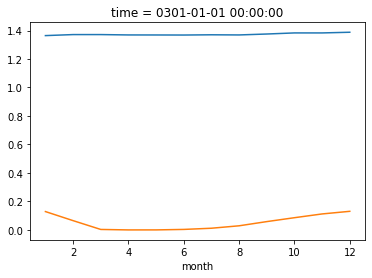

In [45]:
A=ds_circ_lnd.SNOW_DEPTH.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))

A.plot()

B=ds_e4_lnd.SNOW_DEPTH.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time').weighted(weights).mean(dim=('lat','lon'))

B.plot()
#.weighted(weights).mean(dim=('lat','lon'))

<xarray.DataArray ()>
array(0.57916146)
Coordinates:
    time     object 0301-01-01 00:00:00
<xarray.DataArray ()>
array(-0.83752052)
Coordinates:
    time     object 0301-01-01 00:00:00
<xarray.DataArray ()>
array(-1.18456866)
Coordinates:
    time     object 0301-01-01 00:00:00


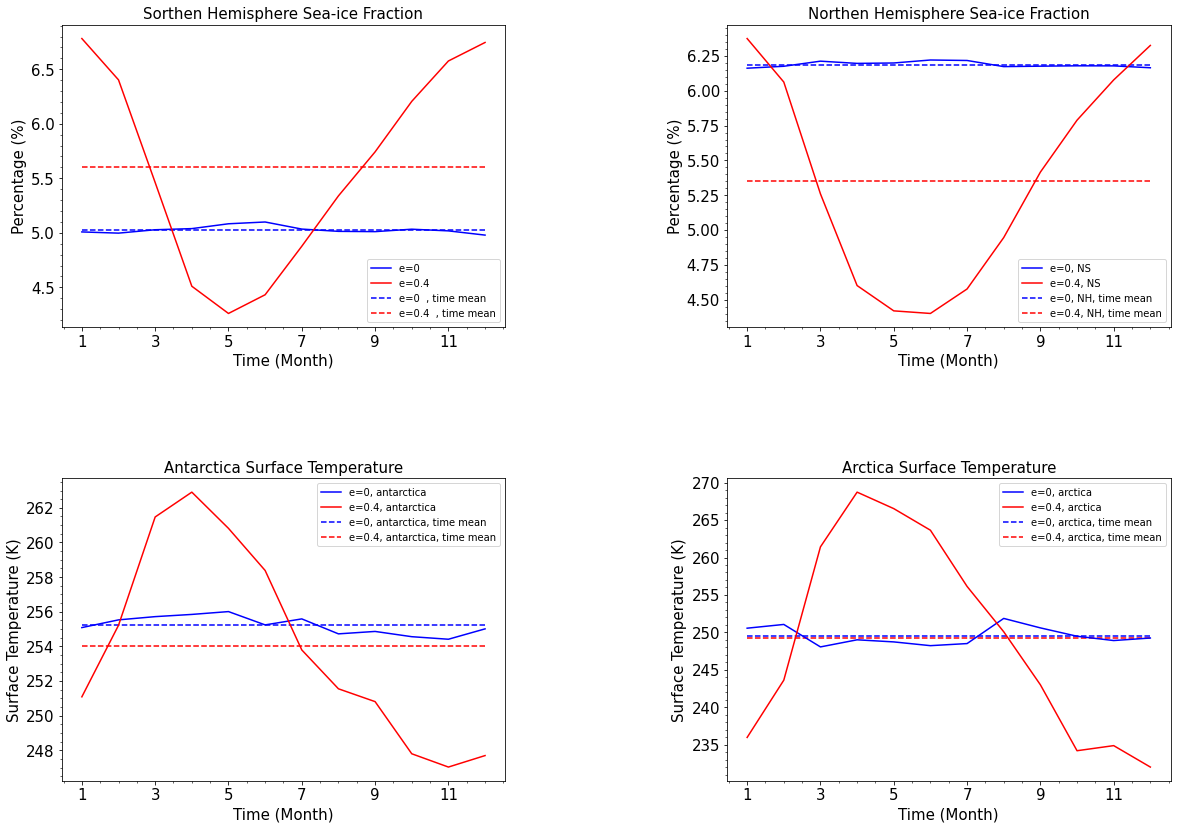

In [77]:
gs = gridspec.GridSpec(2, 2)
plt.figure(figsize=(22,15))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)
##########################################################################################
plt.subplot(gs[0, 0]) # row 0, col 0

A=ds_circ.ICEFRAC.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

A=A.where(A.lat<0)
A=100*A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0  ')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0  , time mean')

B=ds_e4.ICEFRAC.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')
B=B.where(B.lat<0)
B=100*B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4  ')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4  , time mean')

plt.title("Sorthen Hemisphere Sea-ice Fraction",fontsize=15)
plt.xlabel("Time (Month)", fontsize=15)
plt.ylabel("Percentage (%)",fontsize=15)
plt.legend(fontsize=10)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(1, 13, 2.0))
plt.minorticks_on()

print(weighted_annual_mean(B)-weighted_annual_mean(A))
##########################################################################################
plt.subplot(gs[0, 1]) # row 0, col 0
A=ds_circ.ICEFRAC.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

A=A.where(A.lat>0)
A=100*A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0, NS')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, NH, time mean')

B=ds_e4.ICEFRAC.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')
B=B.where(B.lat>0)
B=100*B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4, NS')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, NH, time mean')

plt.title("Northen Hemisphere Sea-ice Fraction",fontsize=15)
plt.xlabel("Time (Month)", fontsize=15)
plt.ylabel("Percentage (%)",fontsize=15)
plt.legend(fontsize=10)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(1, 13, 2.0))
plt.minorticks_on()

print(weighted_annual_mean(B)-weighted_annual_mean(A))
##########################################################################################

plt.subplot(gs[1, 0]) # row 0, col 0
A=ds_circ.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

A=A.where(A.lat<-75).where(DataSet_CAM.mask != 1)
A=A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0, antarctica')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, antarctica, time mean')

B=ds_e4.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')
B=B.where(B.lat<-75).where(DataSet_CAM.mask != 1)
B=B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4, antarctica')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, antarctica, time mean')

plt.title("Antarctica Surface Temperature",fontsize=15)
plt.xlabel("Time (Month)", fontsize=15)
plt.ylabel("Surface Temperature (K)",fontsize=15)
plt.legend(fontsize=10)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(1, 13, 2.0))
plt.minorticks_on()

print(weighted_annual_mean(B)-weighted_annual_mean(A))
##########################################################################################
plt.subplot(gs[1, 1]) # row 0, col 0

A=ds_circ.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

A=A.where(A.lat>75).where(DataSet_CAM.mask != 1)
A=A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0, arctica')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, arctica, time mean')

B=ds_e4.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')
B=B.where(B.lat>75).where(DataSet_CAM.mask != 1)
B=B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4, arctica')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, arctica, time mean')
plt.title("Arctica Surface Temperature",fontsize=15)
plt.xlabel("Time (Month)", fontsize=15)
plt.ylabel("Surface Temperature (K)",fontsize=15)
plt.legend(fontsize=10)
plt.tick_params(labelsize=15)
plt.xticks(np.arange(1, 13, 2.0))
plt.minorticks_on()

plt.savefig("SeaIceFrac_SN_TS.png",dpi=400,bbox_inches="tight")

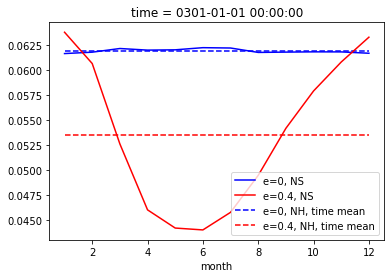

In [47]:
A=ds_circ.ICEFRAC.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

A=A.where(A.lat>0)
A=A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0, NS')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, NH, time mean')

B=ds_e4.ICEFRAC.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')
B=B.where(B.lat>0)
B=B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4, NS')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, NH, time mean')
plt.legend()

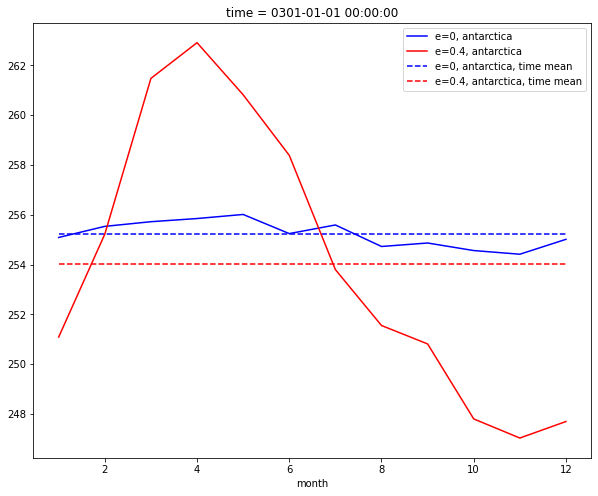

In [48]:
plt.figure(figsize=(10,8))

A=ds_circ.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

A=A.where(A.lat<-75).where(DataSet_CAM.mask != 1)
A=A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0, antarctica')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, antarctica, time mean')

B=ds_e4.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')
B=B.where(B.lat<-75).where(DataSet_CAM.mask != 1)
B=B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4, antarctica')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, antarctica, time mean')
plt.legend()

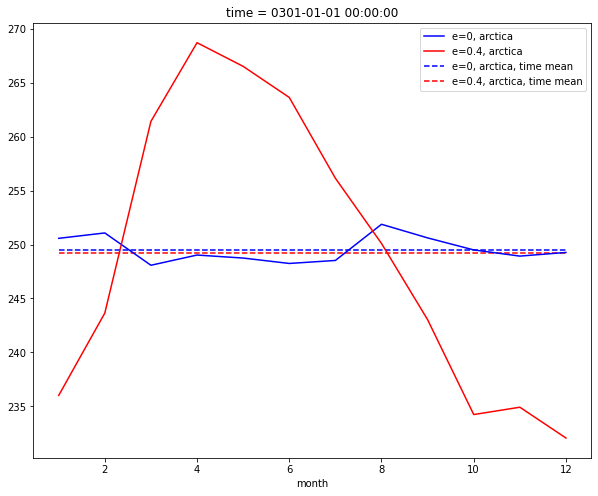

In [49]:
plt.figure(figsize=(10,8))

A=ds_circ.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

A=A.where(A.lat>75).where(DataSet_CAM.mask != 1)
A=A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0, arctica')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, arctica, time mean')

B=ds_e4.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')
B=B.where(B.lat>75).where(DataSet_CAM.mask != 1)
B=B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4, arctica')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, arctica, time mean')
plt.legend()

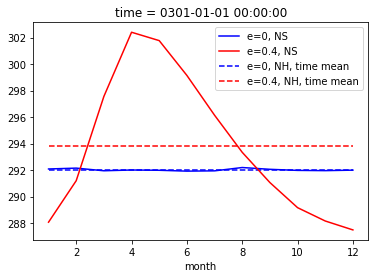

In [50]:
A=ds_circ.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')

A=A.where(A.lat>0).where(DataSet_CAM.mask != 1)
A=A.weighted(weights).mean(dim=('lat','lon'))
A.plot(color='blue',label='e=0, NS')
A['var'] = (['month'], A.values)
plt.hlines(weighted_annual_mean(A),xmin=1,xmax=12,color='blue',linestyle='--',label='e=0, NH, time mean')

B=ds_e4.TS.sel(time=slice('0020-01', '0024-12')).groupby('time.month').mean(dim='time')
B=B.where(B.lat>0).where(DataSet_CAM.mask != 1)
B=B.weighted(weights).mean(dim=('lat','lon'))
B.plot(color='red',label='e=0.4, NS')
B['var'] = (['month'], B.values)
plt.hlines(weighted_annual_mean(B),xmin=1,xmax=12,color='red',linestyle='--',label='e=0.4, NH, time mean')
plt.legend()

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


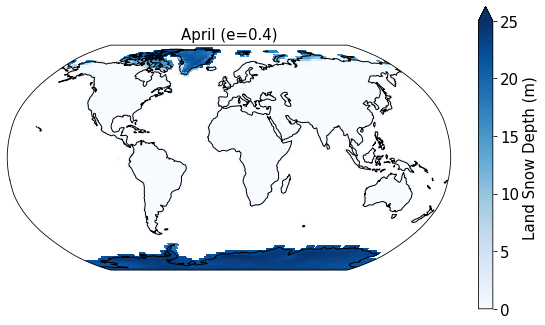

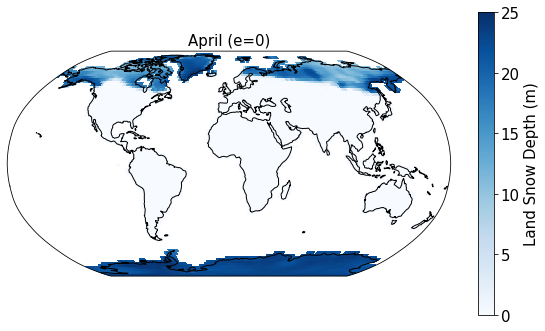

In [51]:
plot_latlon2D(latlon2D_month(ds_e4_lnd.SNOW_DEPTH,timeslice=slice('0020-01', '0024-12'),month=4),title='April (e=0.4)',
              colorbar_label="Land Snow Depth"+" "+"("+ds_e4_lnd.SNOW_DEPTH.attrs["units"]+")",
            colormap='Blues',
              vmin=0,vmax=25,
             unit_converter=1)

plot_latlon2D(latlon2D_month(ds_circ_lnd.SNOW_DEPTH,timeslice=slice('0020-01', '0024-12'),month=4),title='April (e=0)',
              colorbar_label="Land Snow Depth"+" "+"("+ds_circ_lnd.SNOW_DEPTH.attrs["units"]+")",
             colormap='Blues',
              vmin=0,vmax=25,
             unit_converter=1)

In [ ]:
# plotting functions

def plot_latlon2D(x,title,colorbar_label,**kwargs):

    vmin = kwargs.get('vmin', None)
    vmax = kwargs.get('vmax', None)
    unit_converter = kwargs.get('unit_converter', None)
    colormap = kwargs.get('colormap', None)
    discrete_num=kwargs.get('discrete_num', None)    
    
    gs = gridspec.GridSpec(2, 1)
    plt.figure(figsize=(11,15))
    plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.5, 
                    hspace=0.5)

    ax = plt.subplot(gs[0, 0],projection=ccrs.Robinson()) # row 0, col 0
    ax.set_global() 
    ax.coastlines()
    fg=(x*unit_converter).plot(cmap=colormap,transform=ccrs.PlateCarree(),vmin=vmin,vmax=vmax,levels=discrete_num)
    plt.tick_params(labelsize=20)
    plt.minorticks_on()
    fg.colorbar.ax.tick_params(labelsize=15)
    fg.colorbar.set_label(label=colorbar_label, size=15)
    if discrete_num==3:
        fg.colorbar.set_ticklabels(["<30 cm/yr",">30 cm/yr"])
        fg.colorbar.set_ticks([0, 1])
    if discrete_num==13:
        fg.colorbar.set_ticks(list(range(0,13,1)))

    plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)
    plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)
    
    plt.title(title,fontsize=15)



    return(fg)

/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/core.py:121: RuntimeWarning: invalid value encountered in true_divide
  return func(*(_execute_task(a, cache) for a in args))
/nobackup/cemac/software/compilers/python3/3.7.8/1/default/conda/lib/python3.7/site-packages/dask/array/numpy_compat.py:41: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


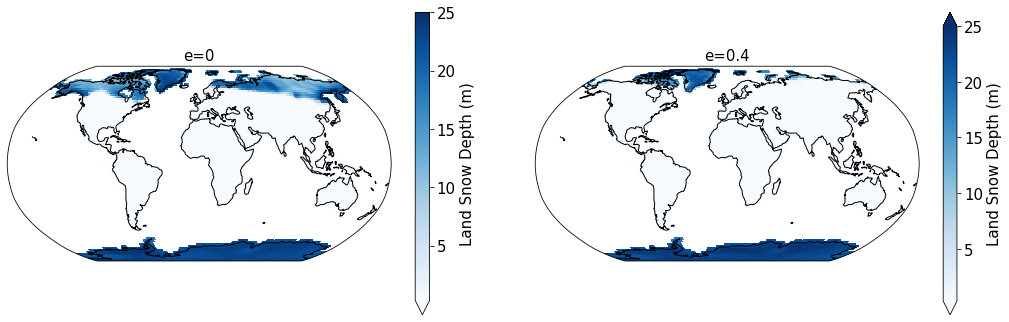

In [122]:
gs = gridspec.GridSpec(1, 2)

plt.figure(figsize=(20,6))

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.1, 
                    hspace=0.5)

x=latlon2D(ds_circ_lnd,"SNOW_DEPTH",timeslice=slice('0020-01', '0024-12'))

ax = plt.subplot(gs[0, 0],projection=ccrs.Robinson()) # row 0, col 0
ax.set_global() 
ax.coastlines()
fg=(x).plot(cmap="Blues",transform=ccrs.PlateCarree(),vmin=0.3,vmax=25)
plt.tick_params(labelsize=20)
plt.minorticks_on()
fg.colorbar.ax.tick_params(labelsize=15)
fg.colorbar.set_label(label="Land Snow Depth"+" "+"("+ds_circ_lnd.SNOW_DEPTH.attrs["units"]+")", size=15)
plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)
plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)
plt.title("e=0",fontsize=15)

###############################################################################################

x1=latlon2D(ds_e4_lnd,"SNOW_DEPTH",timeslice=slice('0020-01', '0024-12'))

ax = plt.subplot(gs[0, 1],projection=ccrs.Robinson()) # row 0, col 0
ax.set_global() 
ax.coastlines()
fg=(x1).plot(cmap="Blues",transform=ccrs.PlateCarree(),vmin=0.3,vmax=25)
plt.tick_params(labelsize=20)
plt.minorticks_on()
fg.colorbar.ax.tick_params(labelsize=15)
fg.colorbar.set_label(label="Land Snow Depth"+" "+"("+ds_e4_lnd.SNOW_DEPTH.attrs["units"]+")", size=15)
plt.xlabel(xlabel='Longitude ($^{\circ}$)',fontsize=20)
plt.ylabel(ylabel='Latitude ($^{\circ}$)',fontsize=20)
plt.title("e=0.4",fontsize=15)

plt.savefig("Lnd_snow.png",dpi=400,bbox_inches="tight")

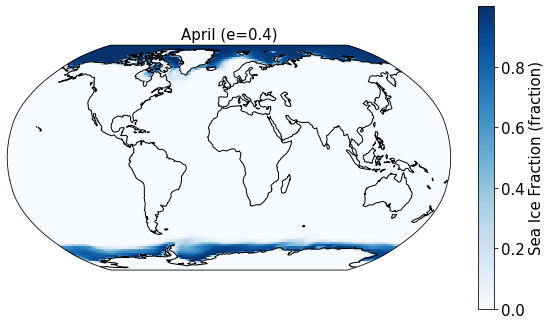

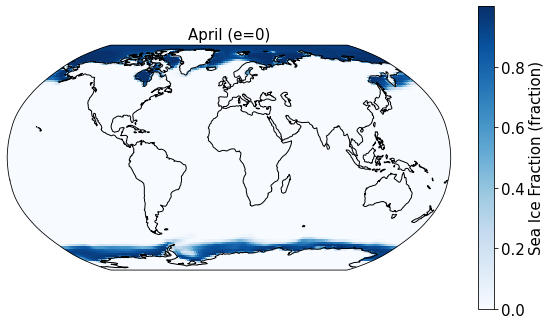

In [53]:
plot_latlon2D(latlon2D_month(ds_e4.ICEFRAC,timeslice=slice('0020-01', '0024-12'),month=4),title='April (e=0.4)',
              colorbar_label="Sea Ice Fraction"+" "+"("+ds_e4.ICEFRAC.attrs["units"]+")",
            colormap='Blues',
             unit_converter=1)

plot_latlon2D(latlon2D_month(ds_circ.ICEFRAC,timeslice=slice('0020-01', '0024-12'),month=4),title='April (e=0)',
              colorbar_label="Sea Ice Fraction"+" "+"("+ds_circ.ICEFRAC.attrs["units"]+")",
             colormap='Blues',
             unit_converter=1)

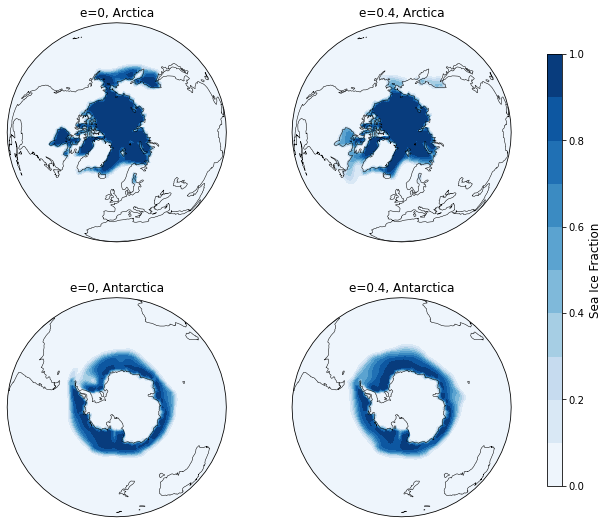

In [54]:
# extract surface temperature and extend it to wrap in longitude (avoids dreaded white strip)
from cartopy.util import add_cyclic_point 

gs = gridspec.GridSpec(2, 2)
fig=plt.figure(figsize=(10,10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.3, 
                    hspace=0.2)
# Generate axes using Cartopy

ax = plt.subplot(gs[0, 0],projection=ccrs.Orthographic(central_longitude=0, central_latitude=90)) # row 0, col 0
ax.set_global() # zoom the map out as much as possible
ax.coastlines(linewidths=0.5) # draw coastlines
ax.set_title('e=0, Arctica')
clevels = np.linspace(0,1,11)


ts = latlon2D(ds_circ,"ICEFRAC",timeslice=slice('0020-01', '0024-12'))

ts_cyc, lon_cyc = add_cyclic_point(ts, coord=ds_circ['lon'])
lat = ds_circ['lat']

# Contourf-plot data (for filled contours)
im = ax.contourf(lon_cyc, lat, ts_cyc, 
             transform=ccrs.PlateCarree(), 
                 levels=clevels,
             cmap='Blues')

ax = plt.subplot(gs[0, 1],projection=ccrs.Orthographic(central_longitude=0, central_latitude=90)) # row 0, col 0
ax.set_global() # zoom the map out as much as possible
ax.coastlines(linewidths=0.5) # draw coastlines
ax.set_title('e=0.4, Arctica')
clevels = np.linspace(0,1,11)

# Contourf-plot data (for filled contours)
ts = latlon2D(ds_e4,"ICEFRAC",timeslice=slice('0020-01', '0024-12'))

ts_cyc, lon_cyc = add_cyclic_point(ts, coord=ds_circ['lon'])
lat = ds_circ['lat']

im = ax.contourf(lon_cyc, lat, ts_cyc, 
             transform=ccrs.PlateCarree(), 
                  levels=clevels,
             cmap='Blues')

#

ax = plt.subplot(gs[1, 0],projection=ccrs.Orthographic(central_longitude=0, central_latitude=-90)) # row 0, col 0
ax.set_global() # zoom the map out as much as possible
ax.coastlines(linewidths=0.5) # draw coastlines
ax.set_title('e=0, Antarctica')
clevels = np.linspace(0,1,11)

ts = latlon2D(ds_circ,"ICEFRAC",timeslice=slice('0020-01', '0024-12'))

ts_cyc, lon_cyc = add_cyclic_point(ts, coord=ds_circ['lon'])
lat = ds_circ['lat']

# Contourf-plot data (for filled contours)
im = ax.contourf(lon_cyc, lat, ts_cyc, 
             transform=ccrs.PlateCarree(), 
                 levels=clevels,
             cmap='Blues')

ax = plt.subplot(gs[1, 1],projection=ccrs.Orthographic(central_longitude=0, central_latitude=-90)) # row 0, col 0
ax.set_global() # zoom the map out as much as possible
ax.coastlines(linewidths=0.5) # draw coastlines
ax.set_title('e=0.4, Antarctica')
clevels = np.linspace(0,1,11)

# Contourf-plot data (for filled contours)
ts = latlon2D(ds_e4,"ICEFRAC",timeslice=slice('0020-01', '0024-12'))

ts_cyc, lon_cyc = add_cyclic_point(ts, coord=ds_circ['lon'])
lat = ds_circ['lat']

im = ax.contourf(lon_cyc, lat, ts_cyc, 
             transform=ccrs.PlateCarree(), 
                  levels=clevels,
             cmap='Blues')


#
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.6])
cb=fig.colorbar(im, cax=cbar_ax,label="Sea Ice Fraction")
cb.set_label(label="Sea Ice Fraction",size='large')

plt.savefig("SeaIceFrac_SN_2D_AM.png",dpi=400,bbox_inches="tight")


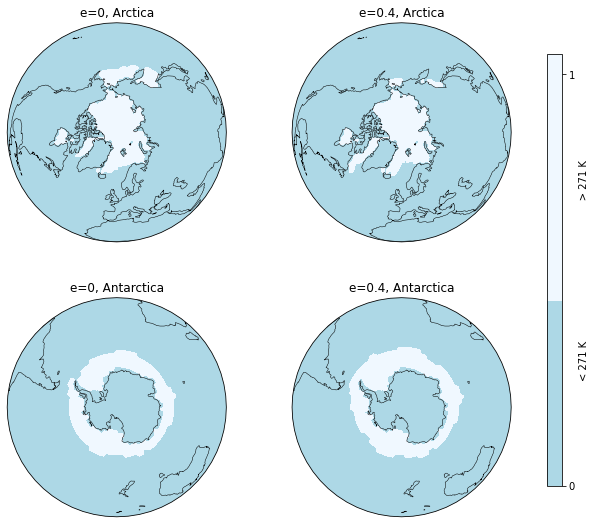

In [55]:
# extract surface temperature and extend it to wrap in longitude (avoids dreaded white strip)
from cartopy.util import add_cyclic_point 

gs = gridspec.GridSpec(2, 2)
fig=plt.figure(figsize=(10,10))
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.8, 
                    top=0.8, 
                    wspace=0.3, 
                    hspace=0.2)
# Generate axes using Cartopy

ax = plt.subplot(gs[0, 0],projection=ccrs.Orthographic(central_longitude=0, central_latitude=90)) # row 0, col 0
ax.set_global() # zoom the map out as much as possible
ax.coastlines(linewidths=0.5) # draw coastlines
ax.set_title('e=0, Arctica')
# clevels = np.linspace(210,273,10)

TS_circ=latlon2D(ds_circ,"TS",timeslice=slice('0020-01', '0024-12')).where(DataSet_CAM.mask != 1)
TS_e4  =latlon2D(ds_e4,"TS",timeslice=slice('0020-01', '0024-12')).where(DataSet_CAM.mask != 1)

ts = np.logical_not(np.isnan((TS_circ/TS_circ).where(TS_circ<271)))

ts_cyc, lon_cyc = add_cyclic_point(ts, coord=ds_circ['lon'])

lat = ds_circ['lat']

# Contourf-plot data (for filled contours)
im = ax.contourf(lon_cyc, lat, ts_cyc, 
             transform=ccrs.PlateCarree(), 
#                  levels=clevels,
             cmap=colors.ListedColormap(['lightblue', 'aliceblue']))

ax = plt.subplot(gs[0, 1],projection=ccrs.Orthographic(central_longitude=0, central_latitude=90)) # row 0, col 0
ax.set_global() # zoom the map out as much as possible
ax.coastlines(linewidths=0.5) # draw coastlines
ax.set_title('e=0.4, Arctica')
# clevels = np.linspace(210,273,10)
# Contourf-plot data (for filled contours)
ts = np.logical_not(np.isnan((TS_e4/TS_e4).where(TS_e4<271)))

ts_cyc, lon_cyc = add_cyclic_point(ts, coord=ds_circ['lon'])
lat = ds_circ['lat']

im = ax.contourf(lon_cyc, lat, ts_cyc, 
             transform=ccrs.PlateCarree(), 
#                   levels=clevels,
             cmap=colors.ListedColormap(['lightblue', 'aliceblue']))

#

ax = plt.subplot(gs[1, 0],projection=ccrs.Orthographic(central_longitude=0, central_latitude=-90)) # row 0, col 0
ax.set_global() # zoom the map out as much as possible
ax.coastlines(linewidths=0.5) # draw coastlines
ax.set_title('e=0, Antarctica')
# clevels = np.linspace(210,273,10)
ts = np.logical_not(np.isnan((TS_circ/TS_circ).where(TS_circ<271)))

ts_cyc, lon_cyc = add_cyclic_point(ts, coord=ds_circ['lon'])
lat = ds_circ['lat']

# Contourf-plot data (for filled contours)
im = ax.contourf(lon_cyc, lat, ts_cyc, 
             transform=ccrs.PlateCarree(), 
#                  levels=clevels,
             cmap=colors.ListedColormap(['lightblue', 'aliceblue']))

ax = plt.subplot(gs[1, 1],projection=ccrs.Orthographic(central_longitude=0, central_latitude=-90)) # row 0, col 0
ax.set_global() # zoom the map out as much as possible
ax.coastlines(linewidths=0.5) # draw coastlines
ax.set_title('e=0.4, Antarctica')
# clevels = np.linspace(210,273,10)
# Contourf-plot data (for filled contours)
ts = np.logical_not(np.isnan((TS_e4/TS_e4).where(TS_e4<271)))

ts_cyc, lon_cyc = add_cyclic_point(ts, coord=ds_circ['lon'])
lat = ds_circ['lat']

im = ax.contourf(lon_cyc, lat, ts_cyc, 
             transform=ccrs.PlateCarree(), 
#                   levels=clevels,
             cmap=colors.ListedColormap(['lightblue', 'aliceblue']))


#

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.6])
space=' '
fig.colorbar(im, cax=cbar_ax,ticks=[0, 1],label="< 271 K"+space*45+"> 271 K")
# fig.colorbar.set_label(label="Sea Ice Fraction", size=15)